# Analisys of the generated data

## Llama-2-7b-chat-hf

https://huggingface.co/meta-llama/Llama-2-7b-chat-hf

1. real
2. baseline
3. targeted + linguistic tags
4. unsupervised context

In [1]:
import os
import re

# CHANGE WORKING DIRECTORY TO ROOT
current_dir = os.path.basename(os.getcwd())
if current_dir == "src":
    os.chdir("..") # Move up by 1
elif os.path.basename(os.getcwd()) == "bai-thesis-nlp":  
    pass # If already at root, stay there
else:
    os.chdir("../..") # Move up by 2 otherwise

import pandas as pd
from src._utils._helpers import get_generated_examples_df
from src._utils._data_analysis_helpers import basic_analysis, check_patterns

analysis_result = []

DATASET = "agnews"
SYN_DATA_DIR = "synthetic_data/datasets/Llama-2-7b-chat-hf/"

# 1. Real data

REAL DATA


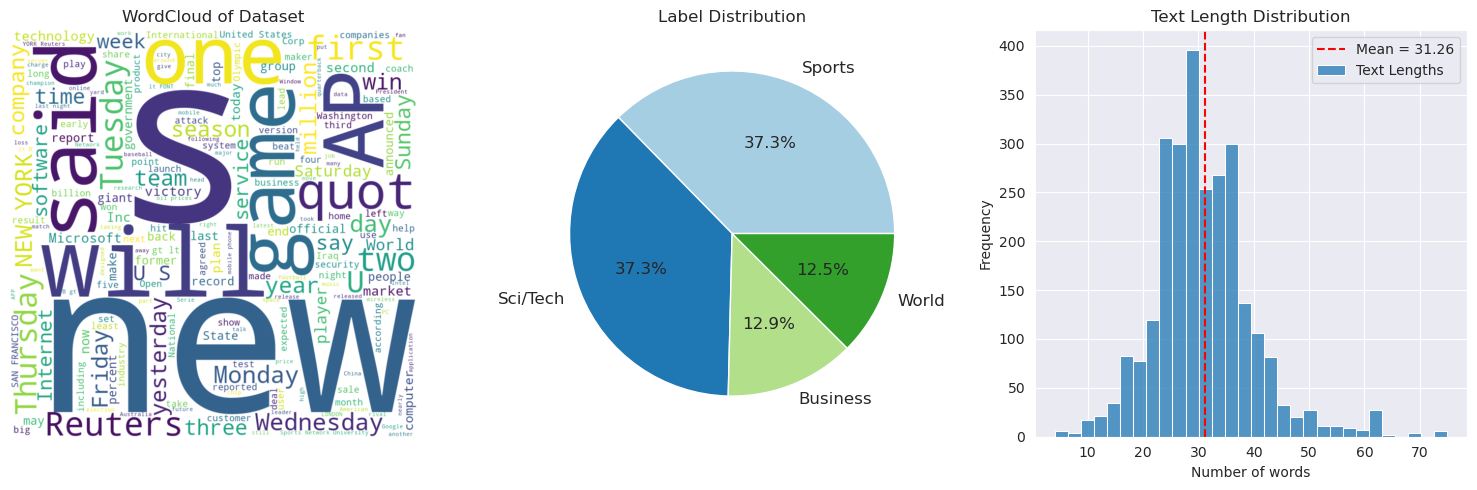

Number of train samples: 2679
Set of labels: {'Sci/Tech', 'Business', 'World', 'Sports'}
Number of labels: 4


In [2]:
print("REAL DATA")
df_real = pd.read_csv("real_data/train/"+DATASET+"trainAll.csv")
df_real = df_real.rename(columns={"2": "text", "3": "label"})
basic_analysis(df_real, print_count_statistics=False, print_missing_values=False)

In [3]:
analysis_result.append(check_patterns(df_real, print_n=3, dataset_name="real"))

Percentage of documents starting with 'A ': 2.91%
Examples:
- A scientific dig has uncovered four pomegranates believed to be 2,500 years old preserved inside a woven basket nestled in a bronze vessel, a Greek archaeologist said Friday.
- A day before federal regulators are expected to free VoIP providers from state taxes, two California cities want their cut.
- A New York City group creates a kit so that anyone with an old computer can create a wireless access point.

Percentage of documents containing 'World Cup': 1.08%
Examples:
- On a clear day, you can see the Chateau Frontenac in Quebec City from her home in Chateau-Richer. But one day, nine years ago, a young volunteer working at a World Cup 
- In LONDON story headlined  quot;Van Nistelrooy plays down hip injury quot;, please read in intro ... World Cup qualifying win ... instead of ... friendly win ... correcting status of match. LONDON, Nov 18 (Reuters) - Manchester 
- Ireland held host France to a 0-0 draw Saturday in a World

# 2. synthetic baseline

In [4]:
path = SYN_DATA_DIR+DATASET+"_baseline_500.json"
df_baseline, metadata = get_generated_examples_df(path)
display(df_baseline.head())
print("Columns :", df_baseline.columns.to_list())
print("Labels  :", df_baseline['label'].unique())

,text,label
0,Lionel Messi scores hat-trick as Barcelona bea...,Sports
1,Lionel Messi scores hat-trick in Barcelona's w...,Sports
2,Rioting Erupts in Hong Kong as Protesters Clas...,World
3,Stock market sees surge in investor optimism a...,Business
4,Company X announces new partnership with indus...,Business


Columns : ['text', 'label']
Labels  : ['Sports' 'World' 'Business' 'Sci/Tech']


RANDOM GENERATION


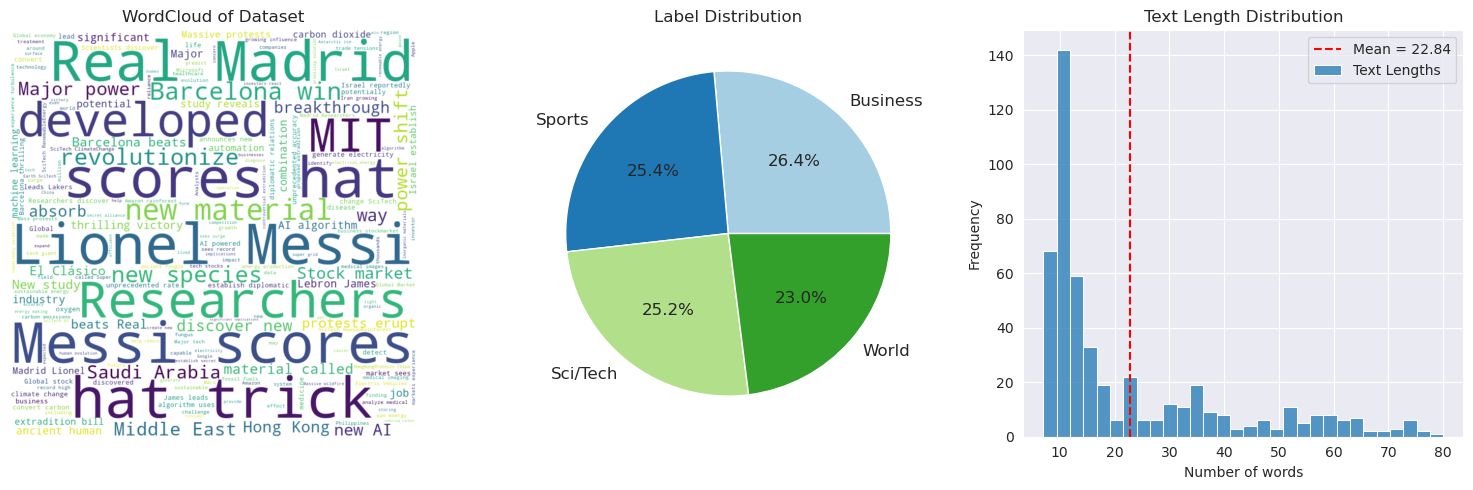

Number of train samples: 500
Set of labels: {'Sci/Tech', 'Business', 'World', 'Sports'}
Number of labels: 4


In [5]:
print("RANDOM GENERATION")
basic_analysis(df_baseline, print_count_statistics=False, print_missing_values=False)

In [6]:
analysis_result.append(check_patterns(df_baseline, print_n=3, dataset_name="baseline"))

Percentage of documents starting with 'A ': 0.00%

Percentage of documents containing 'World Cup': 0.00%

Percentage of documents containing 'AI': 8.40%
Examples:
- Microsoft unveils new AI-powered chatbot for customer service
- Researchers have developed a new AI-powered system that can detect and diagnose diseases with unprecedented accuracy. The system uses machine learning algorithms to analyze medical images and identify patterns that are indicative of specific conditions. The technology has the potential to revolutionize healthcare by improving diagnosis and treatment options for patients around the world. #AI #medicine #healthcare
- Samsung unveils new line of AI-powered smartphones, poised to revolutionize the industry

Percentage of documents containing 'world' (but with label != 'World'): 3.60%
Examples:
- Lewis Hamilton wins record-breaking 7th Formula One World Championship  (label: Sports )
- Stock markets around the world are experiencing a surge in activity as investors 

# 3. synthetic targeted + tags

In [7]:
path = SYN_DATA_DIR+DATASET+"_targeted+tags_500.json"
df_targeted1, metadata = get_generated_examples_df(path)
path = SYN_DATA_DIR+DATASET+"_targeted+tags_500_2.json"
df_targeted2, metadata = get_generated_examples_df(path)
df_targeted = pd.concat([df_targeted1, df_targeted2], ignore_index=True)
display(df_targeted.head())
print("Columns :", df_targeted.columns.to_list())
print("Labels  :", df_targeted['label'].unique())

,text,label,phenomena
0,Lionel Messi scores hat-trick as Barcelona bea...,Sports,"[Record-breaking performance, High-stakes riva..."
1,Lionel Messi scores hat-trick as Barcelona bea...,Sports,"[Lionel Messi's impressive performance, Barcel..."
2,Syrian Refugees Find New Home in Canada,World,"[Refugee Crisis, Immigration Policy, Humanitar..."
3,Microsoft unveils new AI-powered tool to strea...,Business,"[AI adoption, business efficiency, operational..."
4,Microsoft announces new AI-powered chatbot for...,Business,"[AI, chatbot, customer service]"


Columns : ['text', 'label', 'phenomena']
Labels  : ['Sports' 'World' 'Business' 'Sci/Tech']


TARGETED GENERATION


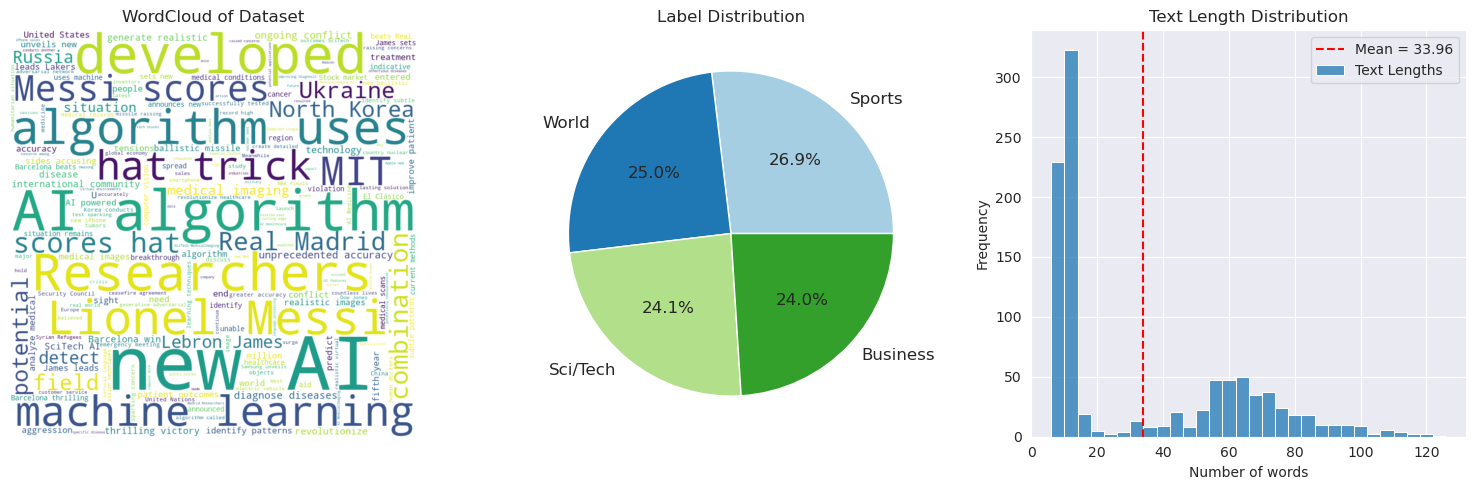

Number of train samples: 1000
Set of labels: {'Sci/Tech', 'Business', 'World', 'Sports'}
Number of labels: 4


In [8]:
print("TARGETED GENERATION")
basic_analysis(df_targeted, print_count_statistics=False, print_missing_values=False)

In [9]:
analysis_result.append(check_patterns(df_targeted, print_n=3, dataset_name="targeted+tags"))

Percentage of documents starting with 'A ': 0.00%

Percentage of documents containing 'World Cup': 0.00%

Percentage of documents containing 'AI': 30.40%
Examples:
- Microsoft unveils new AI-powered tool to streamline business operations
- Microsoft announces new AI-powered chatbot for customer service
- Researchers at MIT have developed a new AI algorithm that can detect and diagnose diseases with unprecedented accuracy. The algorithm uses a combination of machine learning and medical imaging to identify early signs of illness, potentially saving countless lives. #SciTech #Healthcare

Percentage of documents containing 'world' (but with label != 'World'): 4.20%
Examples:
- Stock markets around the world are experiencing a surge in activity as investors pour money into tech stocks. The Nasdaq composite index reached a record high today, driven by gains in companies like Amazon and Microsoft. The Dow Jones Industrial Average also saw significant gains, led by Caterpillar and Boeing. Des

Number of unique phenomena: 1055


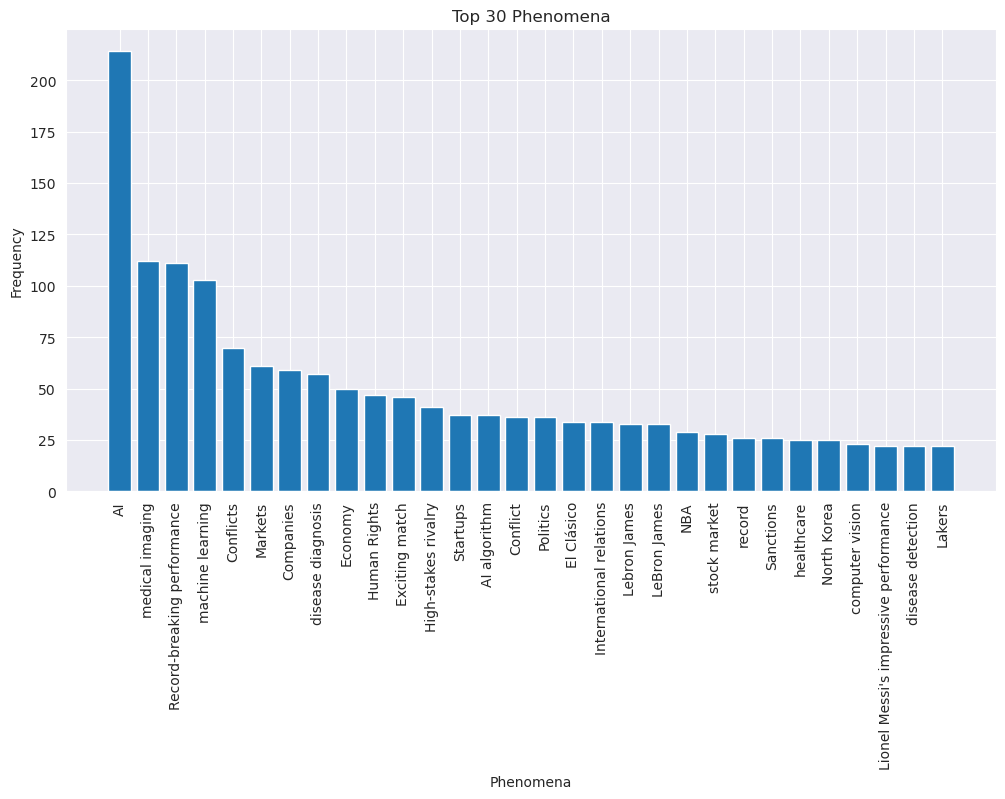

In [10]:
from collections import Counter
import matplotlib.pyplot as plt

# Extract all phenomena into a single list
all_phenomena = [phenomenon for sublist in df_targeted['phenomena'] for phenomenon in sublist]
phenomena_counts = Counter(all_phenomena)
print(f"Number of unique phenomena: {len(phenomena_counts)}")

# plot top n phenomena
n = 30
top_phenomena = phenomena_counts.most_common(n)

plt.figure(figsize=(12, 6))
plt.bar([phenomenon for phenomenon, count in top_phenomena], [count for phenomenon, count in top_phenomena])
plt.xlabel('Phenomena')
plt.ylabel('Frequency')
plt.title(f'Top {n} Phenomena')
plt.xticks(rotation=90)
plt.show()

# 4. Synthetic unsupervised context

In [11]:
path = SYN_DATA_DIR+DATASET+"_unsupervisedContext_500.json"
df_unsupContext, metadata = get_generated_examples_df(path)
display(df_unsupContext.head())
print("Columns :", df_unsupContext.columns.to_list())
print("Labels  :", df_unsupContext['label'].unique())

,text,label,context_examples,requested_label
0,Lionel Messi scores hat-trick as Barcelona bea...,Sports,[With Derek Lowe #39;s days in Boston almost c...,Sports
1,Lionel Messi scores hat-trick as Barcelona bea...,Sports,"[&lt;strong&gt;Letters&lt;/strong&gt; Oh, and ...",Sports
2,The United Nations has announced that it will ...,World,[It is well known that Brett Favre doesn #39;t...,World
3,Amazon announces plans to expand its grocery d...,Business,[Johnny Cash''s instruments and possessions ra...,Business
4,Sony is set to release a new line of high-end ...,Business,"[AP - In a fitting end to the PGA Tour season,...",Business


Columns : ['text', 'label', 'context_examples', 'requested_label']
Labels  : ['Sports' 'World' 'Business' 'Sci/Tech']


UNSUPERVISED CONTEXT


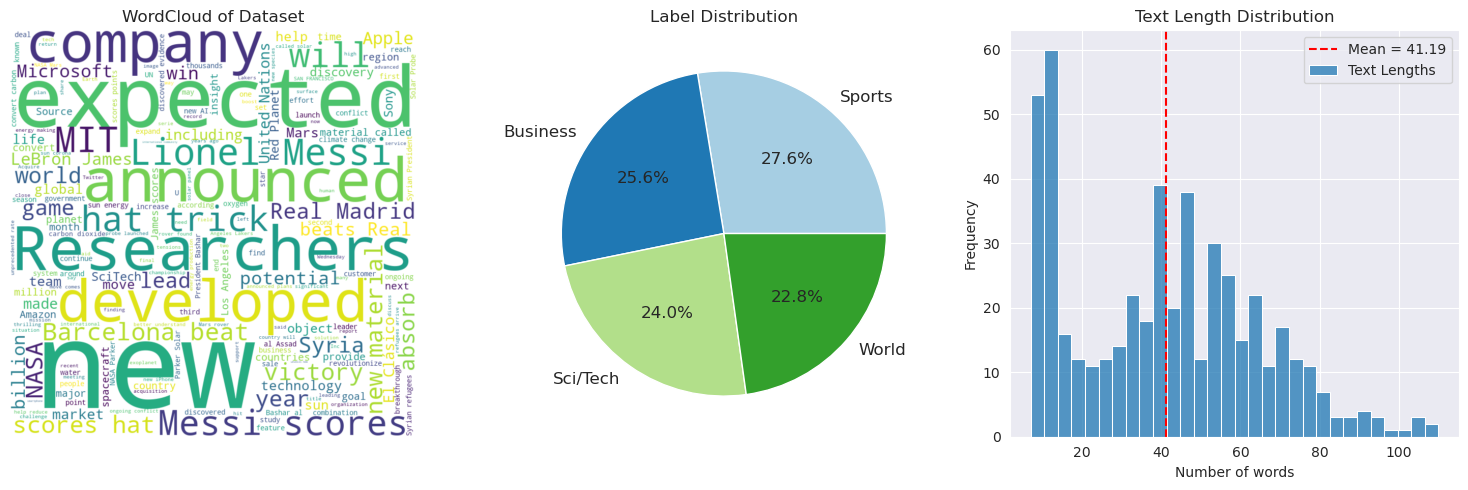

Number of train samples: 500
Set of labels: {'Sci/Tech', 'Business', 'World', 'Sports'}
Number of labels: 4


In [12]:
print("UNSUPERVISED CONTEXT")
basic_analysis(df_unsupContext, print_count_statistics=False, print_missing_values=False)

In [13]:
analysis_result.append(check_patterns(df_unsupContext, print_n=3, dataset_name="unsupervisedContext"))

Percentage of documents starting with 'A ': 0.00%

Percentage of documents containing 'World Cup': 0.00%

Percentage of documents containing 'AI': 5.00%
Examples:
- Salesforce.com has acquired Yet Analytics, a startup that specializes in AI-powered sales forecasting. The acquisition is expected to enhance Salesforce's ability to provide accurate sales projections and help businesses make better decisions.
- Microsoft unveils new AI-powered tool to streamline business operations
- Researchers at MIT have developed a new AI algorithm that can predict the likelihood of a patient developing a severe case of COVID-19 based on their social media activity. The algorithm uses natural language processing to analyze social media posts and identify patterns that indicate a higher risk of severe illness. The study could help healthcare providers prioritize patients who need closer monitoring and treatment.

Percentage of documents containing 'world' (but with label != 'World'): 2.80%
Examples:
- W


---

# Comparison

In [15]:
df_analysis = pd.DataFrame(analysis_result)

display(df_analysis.round(2))

,dataset_name,n_documents,avg_length,starts_with_A_,world_cup,ai,world_in_non_world_label,non_latin
0,real,2679,31.26,2.91,1.08,0.0,5.75,0.0
1,baseline,500,22.84,0.00,0.00,8.4,3.60,0.0
2,targeted+tags,1000,33.96,0.00,0.00,30.4,4.20,0.0
3,unsupervisedContext,500,41.19,0.00,0.00,5.0,2.80,0.0


Columns meaning memo:
- `starts_with_A_`: % of docs starting with 'A '
- `world_cup`: % of docs containing 'world cup' 
- `ai`: % of docs containing 'ai' 
- `world_in_non_world_label`: % of docs containing 'world', but with the label != 'World'
- `non_latin`: % of docs containing non-latin characters

In [21]:

for i in range(5):
    print(df_baseline["text"][i])
    print(df_targeted["text"][i])
    print(df_unsupContext["text"][i])
    print("-" * 50)


Lionel Messi scores hat-trick as Barcelona beats Real Madrid 3-2 in El Clásico
Lionel Messi scores hat-trick as Barcelona beats Real Madrid in El Clásico
Lionel Messi scores hat-trick as Barcelona beats Real Madrid 3-2 in El Clásico
--------------------------------------------------
Lionel Messi scores hat-trick in Barcelona's win over Real Madrid
Lionel Messi scores hat-trick as Barcelona beats Real Madrid 3-2 in El Clásico
Lionel Messi scores hat-trick as Barcelona beats Real Madrid in El Clásico
--------------------------------------------------
Rioting Erupts in Hong Kong as Protesters Clash with Police
Syrian Refugees Find New Home in Canada
The United Nations has announced that it will be providing aid to a drought-stricken region in Africa, after a severe drought has left millions of people without access to clean water. The organization has called on other countries to join in the effort to provide relief to those in need.
--------------------------------------------------
Stoc

we get this strange behaviour for "Lionel Messi" as first response even with different prompts. But the seed for the different generations is the same, so maybe this is the reason.